Before you turn this problem in, make sure everything runs as expected. First, **restart the kernel** (in the menubar, select Kernel $\rightarrow$ Restart) and then **run all cells** (in the menubar, select Cell $\rightarrow$ Run All).

Make sure you fill in any place that says `YOUR CODE HERE` or "YOUR ANSWER HERE", as well as your name and collaborators below: 


In [78]:
NAME = "Angelina Podolako"
STUDENT_NUMBER = "s1125886"

### Important: When handing in your homework:
- Hand in the notebook named as follows: Studentname_snumber.ipynb
- If you find any mistakes/have suggestions/like to complain about the material, please e-mail Emma at `emma.gerritse@ru.nl`
- Do not remove any cells in the notebook, as it might break the auto-grader
- When using platforms other than Jupyter Notebooks to make your assignments, it might remove the auto-grading metadata. To prevent this, please copy the answers back into the original notebook.
- Only type your answers in places where asked.   

To make sure your answers work correctly, please make sure to use the variable names as given in the assignment. This will look like:

```
    some_variablename = None

    # YOUR CODE HERE
    raise NotImplementedError()
```
You can remove the `raise NotImplementedError()` and answer the assignment as follows:

```
    some_variablename = None
    # YOUR CODE HERE
    your_code
    more_code
    some_variable = some_results
```

Not using the specified variable names may result in reduced points.

---

# Assignment 2: Logistic regression, train/test split, evaluation

## Deadline: October 2nd, 23:59

In this assignment, you will learn: 
 - How to implement logistic regression with stochastic batch-wise gradient descent
 - Different strategies for imputing data
 - More tactics for visualization
 - How to compute Accuracy, ROC and AUC
 - How to use packages for logistic regression and metrics.

Again, in case you get stuck anywhere, you can always try continuing to the next exercise. 

Last time, we used the Penguin dataset to predict the weight of the penguin. Now, we will predict the species of the penguin, based on different features. 
In case you don't have the CSV ready anymore, download it here. 

In [83]:
!curl -o penguin.csv https://raw.githubusercontent.com/mwaskom/seaborn-data/master/penguins.csv

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed

  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100 13478  100 13478    0     0   304k      0 --:--:-- --:--:-- --:--:--  321k


To make sure the rest of this part of the assignment goes smoothly, we will pre process the penguin dataset for you.


If you want to learn more about the MinMaxScaler, check out the [documentation here](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.MinMaxScaler.html) . We will learn more about this in later assignments. 

In [85]:
import pandas as pd
import numpy as np


penguins = pd.read_csv("penguin.csv")
penguins_processed = penguins.dropna().copy()

To do a bit more data exploration, we will look at a [Scatterplot matrix](https://plotly.com/python/splom/) ;

This is an easy way to plot multiple features. 
Look through this scatter matrix and think:

- Which penguin species is easiest to predict? (Adelie, Chinstrap, or Gentoo)?
- Which feature is best for predicting this? (Bill length, Bill depth, Flipper length, Body mass?)


(*Note, in case you get an attribute error, make sure your plotly version is at least 5.9.0*)

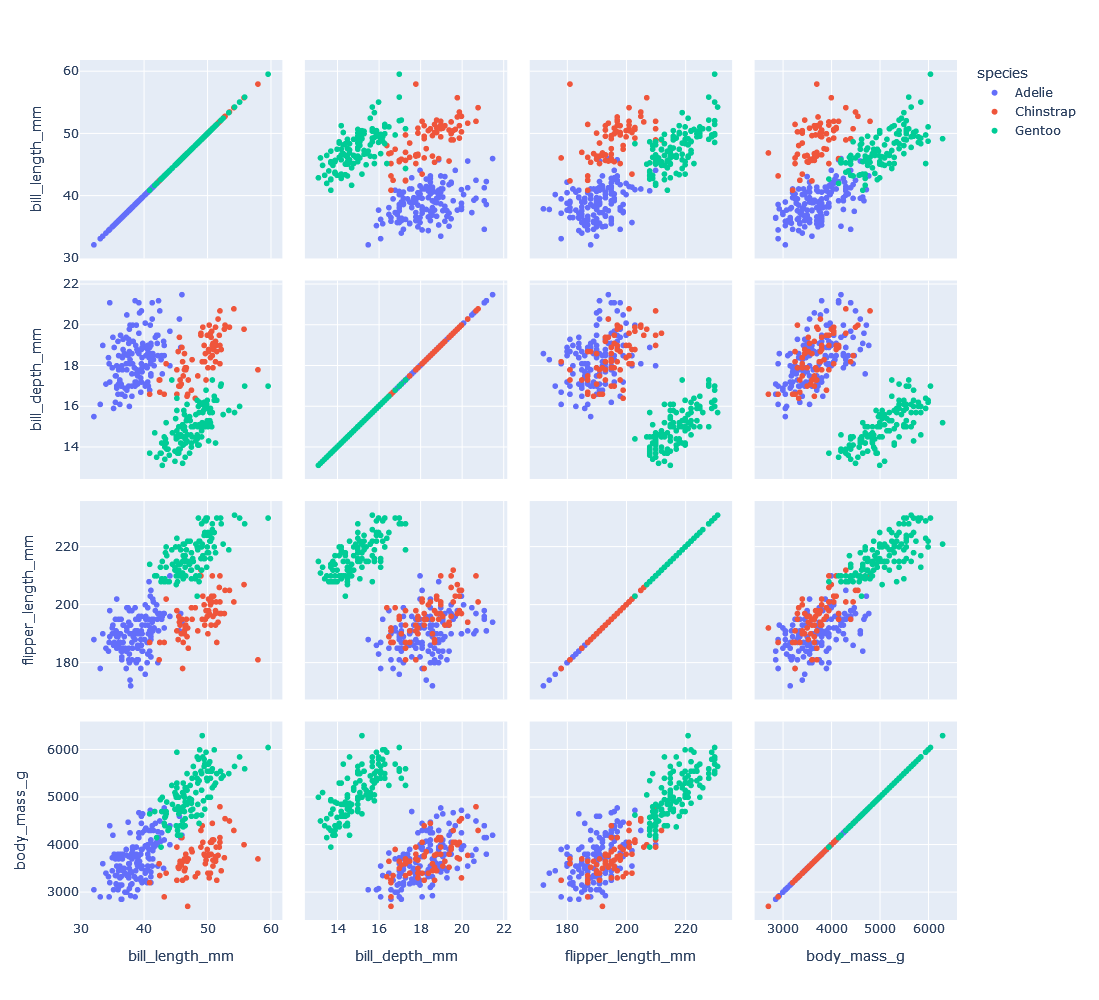

In [87]:
import plotly.express as px

features = ["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]

fig = px.scatter_matrix(penguins_processed, dimensions=features, color="species")
fig.update_layout(
    autosize=False,
    width=1000,
    height=1000,
)
fig.show()

### Exercise 1.1


Judging from the plots above, the easiest species of penguins to classify is `Gentoo` (why?). Thus we will classify 'Gentoo' and 'Not Gentoo'. 

Using Pandas, it's easy to add a column. Take a look here:
https://pandas.pydata.org/docs/getting_started/intro_tutorials/05_add_columns.html 
and here:
https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.apply.html

First, make the NumPy array X using the feature `bill_depth_mm`, resulting in an `(333,1)` shaped array.

Then, add a column 'Gentoo' to the Penguin dataframe, which is `True` for Gentoo penguins and `False` for the other Penguins.
Create the numpy array `y` shaped `(333,)` where the value is '1' for a Gentoo penguin and '0' for a not Gentoo penguin.




In [91]:
X = None
penguins_processed["Gentoo"] = np.nan
y = None
feature = ["bill_depth_mm"]


# YOUR CODE HERE
X = penguins_processed["bill_depth_mm"].to_numpy().reshape(-1,1)
penguins_processed["Gentoo"] = penguins_processed["species"] == "Gentoo"
y = penguins_processed["Gentoo"].apply(lambda x: 1 if x else 0).to_numpy()
feature = ["bill_depth_mm"]

In [92]:
"""Checks whether previous output is correct"""
"""DO NOT MODIFY THIS CELL"""


'DO NOT MODIFY THIS CELL'

### Exercise 1.2
Last time, we did not use a train-test split, to simplify the assignment a little bit. 
Starting this time, we will _always_ do a train-test split! 
Use the documentation of [SK learn](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html) to create a train-test split of the penguins. 


Make a train test split with the specified variable names and the specified random seed and test size.

In [94]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler


X_train = None
X_test = None
y_train = None
y_test = None
random_seed = 42
test_size = 0.25


# YOUR CODE HERE
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state = random_seed)


# We will scale the data for you, to make your life a bit easier
# Note that we fit the scaler on the train data and then fit it on the test data
# Otherwise we would leak data
scaler = MinMaxScaler()
scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

In [95]:
"""Checks whether previous output is correct"""
"""DO NOT MODIFY THIS CELL"""


'DO NOT MODIFY THIS CELL'

### Exercise 1.3

Let's implement the formula of the logistic function, as seen below:

$$ h(x) = \frac{1}{1+e^{-(x\cdot w + b)}} $$

Simular to the function you made last time for linear regression, make a function that given a matrix X of shape (N,m), a weight matrix of shape (m,1) and a float value bias, and make sure the resulting vector has _the same shape as y_ .

[Numpy Divide](https://numpy.org/doc/stable/reference/generated/numpy.divide.html) and [Numpy Exp](https://numpy.org/doc/stable/reference/generated/numpy.exp.html) might be useful. 

In [97]:
def evaluate_set(X, weight, bias):
    # YOUR CODE HERE
    return 1/(1+ np.exp(-1 * (np.dot(X, weight)+bias) ) )

In [98]:
"""Checks whether previous output is correct"""
"""DO NOT MODIFY THIS CELL"""

'DO NOT MODIFY THIS CELL'

### Exercise 1.4 

Run the following two cells to test if you implemented your function correctly.

If correct, all predictions should be somewhat accurate. 

If you want, you can edit the values for `w` and `b` to see what happens to the logistic function.

Get a feeling for what happens when `w` becomes larger/smaller, and when `b` becomes larger/smaller.

Which of these functions do you feel is most _likely_ to predict y_test?

In [101]:
preds = [
    evaluate_set(X_test, np.array([-21]), 8),
    evaluate_set(X_test, np.array([-19]), 8),
    evaluate_set(X_test, np.array([-21]), 6),
    evaluate_set(X_test, np.array([-21]), 10),
    evaluate_set(X_test, np.array([-23]), 8),
]

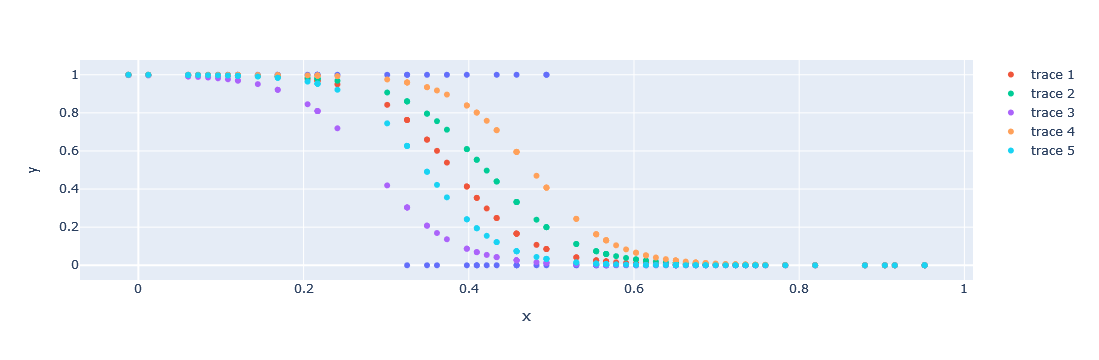

In [106]:
fig = px.scatter(x=X_test[:, 0], y=y_test)
for pred in preds:
    fig.add_scatter(x=X_test[:, 0], y=pred, mode="markers")
fig.show()

Great! Now let's figure out how well we did. For that, we are going to use the _Log likelihood_ .

$$\text{Log Likelihood} (\hat{y}, y) = \sum_{i=1}^n y^{(i)}\log (h(x^{(i)})) + (1-y^{(i)}) \log(1-h(x^{(i)}))$$

In [111]:
def log_likelihood(pred, y):
    positives = np.multiply(y, np.log(pred))
    negatives = np.multiply(1 - y, np.log(1 - pred))
    return np.sum(positives + negatives)

In [112]:
# Let's explore all the log likelihoods of the predictions we made above:
# Does this agree with which functions you thought were most likely?
for pred in preds:
    print(log_likelihood(pred, y_test))

-17.572975608846544
-18.340552065105864
-27.801382129528882
-25.570697276383733
-19.91011614375751


### Exercise 1.5

Reuse your gradient descent function of last week.
You should be able to exactly reuse the part you wrote in the function of last week, given that you call the evaluate_set function in this function. 
This time, we will add two arrays `all_weight` and `all_bias`, so we can plot the path of the gradient later.

In [114]:
def gradient_descent(x, y, lr, steps):
    N, dim = x.shape
    weights = np.ones((dim))
    bias = 0
    all_weights = []
    all_bias = []
    for i in range(steps):
        # YOUR CODE HERE
        y_prime = evaluate_set(x, weights, bias) #predicted y
        result = y - y_prime #difference between predicted and real data
        weights = weights + lr * np.dot(x.T, result) / N #gradient step to update weights
        bias = bias + lr * np.sum(result) / N
        
        all_weights.append(weights[0]) #save current w
        all_bias.append(bias)
    return weights, bias, all_weights, all_bias

### Exercise 1.6

Play around with the values of `learning_rate` and `steps` until you get an acceptable answer.
Use the plots below to get more insights into your predictions. 

(_note that you can just remove the `YOUR CODE HERE` part and change the first two lines_)

In [116]:
learning_rate = 0.1  # Edit this variable
steps = 1  # Edit this variable

# YOUR CODE HERE
learning_rate = 0.1
steps = 15000


gw_weights, gw_bias, weightvec, biasvec = gradient_descent(
    X_train, y_train, learning_rate, steps
)
print(gw_weights, gw_bias)

[-17.82763903] 6.76861899809755


In [118]:
"""Checks whether previous output is correct"""
"""DO NOT MODIFY THIS CELL"""


'DO NOT MODIFY THIS CELL'

Let's plot the prediction to see if our prediction makes sense:

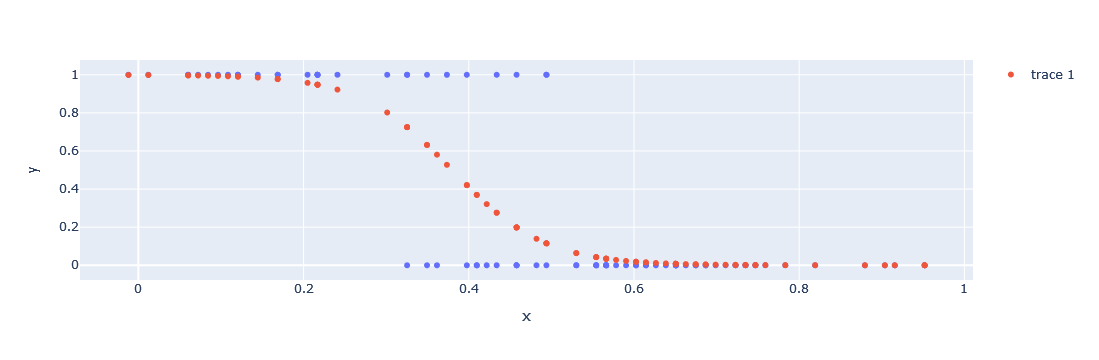

In [120]:
pred = evaluate_set(X_test, gw_weights, gw_bias)
fig = px.scatter(x=X_test[:, 0], y=y_test)
fig.add_scatter(x=X_test[:, 0], y=pred, mode="markers")
fig.show()

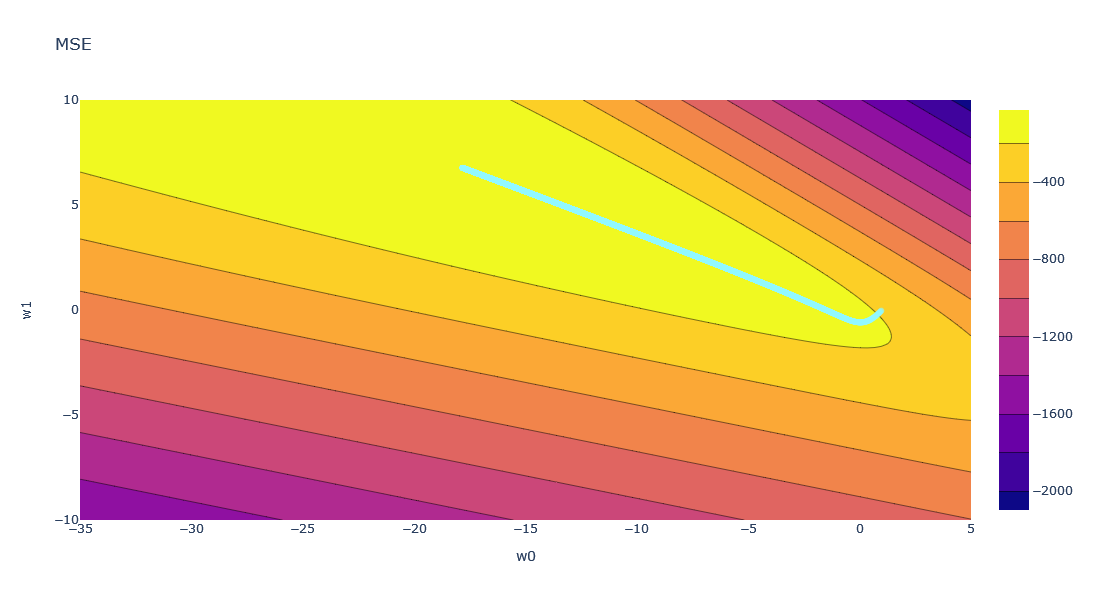

In [121]:
# Use this plot to inspect the bath of the gradient descent. Try investigating the path of the weight/bias

import plotly.graph_objects as go

# You can change the first two values in x_plot and y_plot below to change the range of the x and y axis.
weights_plot = np.linspace(-35, 5, 130)
bias_plot = np.linspace(-10, 10, 130)

# Next we will create our mesh grid, this will create two 2-D arrays. One contains the x-value,
# and one contains the y-value
ww, bb = np.meshgrid(weights_plot, bias_plot)


# np.vectorize is very similar to a map in functional programming, and allows us
# to be able to use any function on an entire array
@np.vectorize
def vectorized_MLL(weights, bias):
    return log_likelihood(evaluate_set(X_train, np.array([weights]), bias), y_train)


MLL = vectorized_MLL(ww, bb)

fig = go.Figure(
    data=go.Contour(
        z=MLL,
        x=weights_plot,  # horizontal axis
        y=bias_plot,  # vertical axis
        line_smoothing=0.10,
    )
)
# Add the scatter of the plotted weights
fig.add_trace(
    go.Scatter(
        x=weightvec,
        y=biasvec,
        name="Gradient descent",
        mode="lines+markers",
        marker_color="rgba(145, 249, 255, .5)",
    ),
)

fig.update_layout(
    autosize=False,
    width=600,
    height=600,
    xaxis_title="w0",
    yaxis_title="w1",
    title="MSE",
)
fig.show()

### Exercise 1.7

Let's add batched stochastic gradient descent to our toolkit. 
For this, we will add an extra loop inside our loop, where we will compute the gradients over small random parts of the datasets, called batches.

We will use the [np.random.permutation](https://numpy.org/doc/stable/reference/random/generated/numpy.random.permutation.html) function to shuffle the indexes.

Recall that you can also index np arrays using other numpy arrays, 

so if `A = np.array([3,6,9,12]), B = np.array([1,3])`
`A[B] = [6,12]`


Use this to make two arrays x_mini and y_mini with the perm indexes, and then compute the gradient like you did before.

In [127]:
def stochastic_gradient_descent(x, y, lr, steps, batch_size):
    N, dim = x.shape
    weights = np.ones((dim))
    bias = 0
    weightvec = []
    biasvec = []
    for i in range(steps):
        permutation = np.random.permutation(N)
        for i in range(0, N, batch_size):
            perm = permutation[i : i + batch_size]
            # YOUR CODE HERE
            x_mini = x[perm]
            y_mini = y[perm]

            y_prime = evaluate_set(x_mini, weights, bias) #predicted y
            result = y_mini - y_prime #difference between predicted and real data
            
            weights = weights + lr * np.dot(x_mini.T, result) / batch_size #gradient step to update weights
            bias = bias + lr * np.sum(result) / batch_size
            
            weightvec.append(weights[0])
            biasvec.append(bias)
    return weights, bias, weightvec, biasvec

### Exercise 1.8

Play around with the values of `learning_rate`,  `steps` and `batch_size` until you get an acceptable answer.

Use the plots below to get more insights into your predictions. 

(_note that you can just remove the `YOUR CODE HERE` part and change the first three lines_)

In [129]:
learning_rate = 0.1  # Edit this variable
steps = 10000  # Edit this variable
batch_size = 64 # Edit this variable


(
    gw_weights_stoch,
    gw_bias_stoch,
    weightvec_stoch,
    biasvec_stoch,
) = stochastic_gradient_descent(X_train, y_train, learning_rate, steps, batch_size)
print(gw_weights_stoch, gw_bias_stoch)

[-23.54137533] 9.025878399187645


In [130]:
"""Checks whether previous output is correct"""
"""DO NOT MODIFY THIS CELL"""


'DO NOT MODIFY THIS CELL'

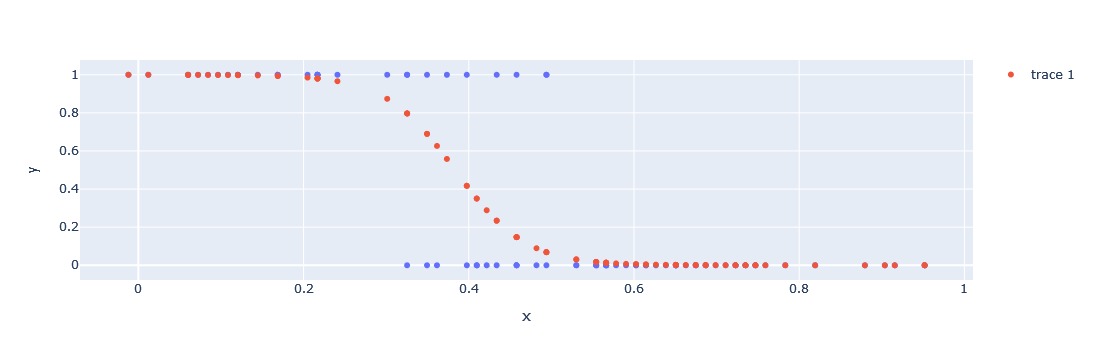

In [131]:
# Use this plot to see if your prediction makes sense

pred = evaluate_set(X_test, gw_weights_stoch, gw_bias_stoch)
fig = px.scatter(x=X_test[:, 0], y=y_test)
fig.add_scatter(x=X_test[:, 0], y=pred, mode="markers")
fig.show()

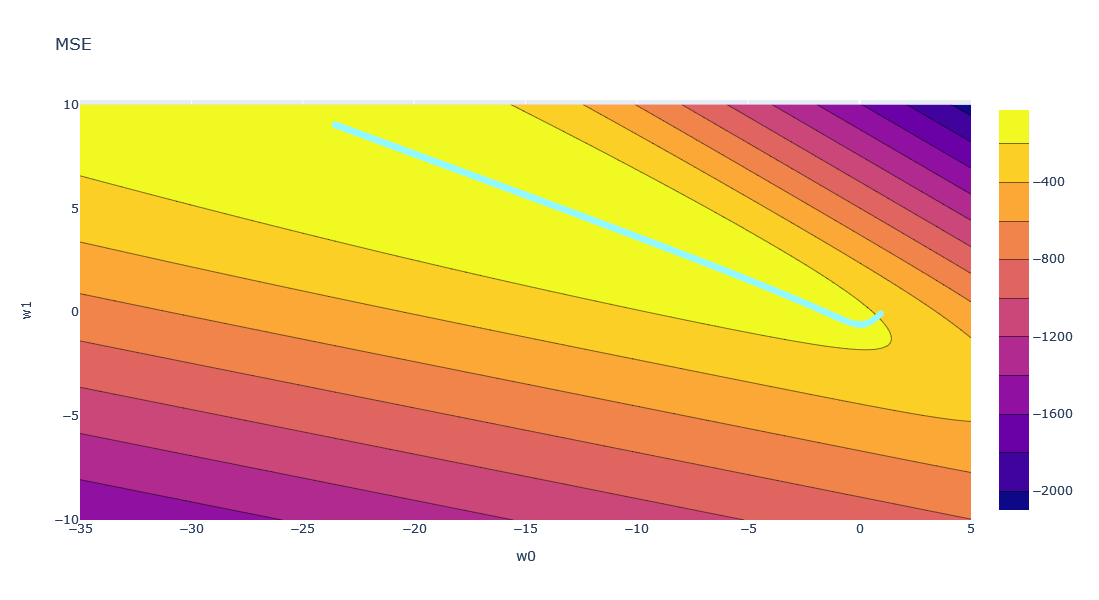

In [143]:
# Use this plot to inspect the bath of the gradient descent. Try investigating the path of the weight/bias
# Can you see that the gradient path is more wobbly here? Try changing the values of the batch size

fig = go.Figure(
    data=go.Contour(
        z=MLL,
        x=weights_plot,  # horizontal axis
        y=bias_plot,  # vertical axis
        line_smoothing=0.10,
    )
)
# Add the scatter of the plotted weights
fig.add_trace(
    go.Scatter(
        x=weightvec_stoch,
        y=biasvec_stoch,
        name="Gradient descent",
        mode="lines+markers",
        marker_color="rgba(145, 249, 255, .5)",
    ),
)

fig.update_layout(
    autosize=False,
    width=600,
    height=600,
    xaxis_title="w0",
    yaxis_title="w1",
    title="MSE",
)
fig.show()

# Part for WEEK 4:

Note, this part is to be done after you have attended the 4th lecture. You can work ahead, but we can't promise that the TA's can already help you with this part. If you get stuck in Exercise 2, try continuing to Exercise 3. 

### Exercise 2.1


## Evaluation

Now, we will compute some evaluations. Based on a certain threshold, we'll make functions for the true positives, false positives, true negatives, and false negatives. 

Tip: we can use some Numpy functionality to compare two arrays.

First of all, we can compare all elements of a numpy array using Boolean operators. For example
`np.array([0 , 1])>0.5` will return `array([False, True])`

Next, we can elementwise compare two NumPy arrays with [np.equal](https://numpy.org/doc/stable/reference/generated/numpy.equal.html) .

Note that `True` and `False` are the same as `1` and `0`,

so `np.equal(np.array([0,1,0,1]), np.array([False, True, True, False]))`

will result in `array([ True,  True, False, False])`

You can use the functions `np.logical_and`, `np.logical_or`, `np.logical_not` and `np.logical_xor` in a similar way. 

Next, if you want to compute the number of times `True` is used in an array, we can just use the `np.sum`.

So `np.sum(np.array([True, True, False, False]))` will result in `2`. 

Using this, make functions for the following metrics: 

In [160]:
### Return the number of true positives given a certain threshold
def true_positive(pred, y, threshold=0.5):
    # YOUR CODE HERE
    return np.sum(np.logical_and(pred >= threshold, y == True)) #prediction greater than threshold, and y = True

In [161]:
### Return the number of true negatives given a certain threshold


def true_negative(pred, y, threshold=0.5):
    # YOUR CODE HERE
    return np.sum(np.logical_and(pred < threshold, y == False))

In [182]:
### Return the number of false positives given a certain threshold


def false_positive(pred, y, threshold=0.5):
    # YOUR CODE HERE
    return np.sum(np.logical_and(pred >= threshold, y == False))

In [183]:
### Return the number of false negatives given a certain threshold


def false_negative(pred, y, threshold=0.5):
    # YOUR CODE HERE
    return np.sum(np.logical_and(pred < threshold, y == True))

In [184]:
### Use this cell to test:
### NOTE: FP+FN+TP+TN should be equal to total, so for this example the total should add up to 6 
predictions = np.array([0.1, 0.3, 0.4, 0.5, 0.8, 0.9])
ground_truth = np.array([False, False, True, True, False, True])

threshold = 0.45
print(true_positive(predictions, ground_truth, threshold))
print(true_negative(predictions, ground_truth, threshold))
print(false_positive(predictions, ground_truth, threshold))
print(false_negative(predictions, ground_truth, threshold))

2
2
1
1


In [185]:
"""Checks whether previous output is correct"""
"""DO NOT MODIFY THIS CELL"""


'DO NOT MODIFY THIS CELL'

### Exercise 2.2

Now we can use these to compute the following other metrics. Reuse the functions you made above:

$$     \texttt{True Positive Rate} = \frac{\texttt{TP}}{\texttt{TP+FN}} $$
$$     \texttt{False Positive Rate} = \frac{\texttt{FP}}{\texttt{FP+TN}} $$



In [194]:
def true_positive_rate(pred, y, threshold=0.5):
    # YOUR CODE HERE
    return (true_positive(pred, y, threshold) / ( true_positive(pred, y, threshold) + false_negative(pred, y, threshold) ))

In [196]:
def false_positive_rate(pred, y, threshold=0.5):
    # YOUR CODE HERE
        return (false_positive(pred, y, threshold) / ( false_positive(pred, y, threshold) + true_negative(pred, y, threshold) ))

In [198]:
## Use this cell to inspect your answer

predictions = np.array([0.1, 0.3, 0.4, 0.5, 0.8, 0.85, 0.89, 0.9])
ground_truth = np.array([False, False, True, True, False, True, True, True])

threshold = 0.5
print(true_positive_rate(predictions, ground_truth, threshold))
print(false_positive_rate(predictions, ground_truth, threshold))

0.8
0.3333333333333333


In [200]:
"""Checks whether previous output is correct"""
"""DO NOT MODIFY THIS CELL"""


'DO NOT MODIFY THIS CELL'

### Exercise 2.3

Next, we will implement the ROC curve: 

- Iterate through all the thresholds
- compute the TPR and FPR for those thresholds
- append the values to the arrays `tpr` and `fpr`

In [203]:
def ROC(predictions, true):
    tpr = []
    fpr = []

    for threshold in predictions:
        # YOUR CODE HERE
        fpr.append(false_positive_rate(predictions, true , threshold))
        tpr.append(true_positive_rate(predictions, true , threshold))
    return tpr, fpr

In [205]:
# Use this cell to test the code above.

predictions = np.array([0.1, 0.3, 0.4, 0.5, 0.8, 0.85, 0.89, 0.9])
true = np.array([False, False, True, True, False, True, True, True])

roc_tpr, roc_fpr = ROC(predictions, true)

print(roc_tpr, roc_fpr)

[1.0, 1.0, 1.0, 0.8, 0.6, 0.6, 0.4, 0.2] [1.0, 0.6666666666666666, 0.3333333333333333, 0.3333333333333333, 0.3333333333333333, 0.0, 0.0, 0.0]


In [207]:
"""Checks whether previous output is correct"""
"""DO NOT MODIFY THIS CELL"""


'DO NOT MODIFY THIS CELL'

### Exercise 2.4

Plot the resulting ROC, where you have the FPR on the x-axis and the TPR on the y-axis.

Hint: All plotted points should be above the line $y=x$.

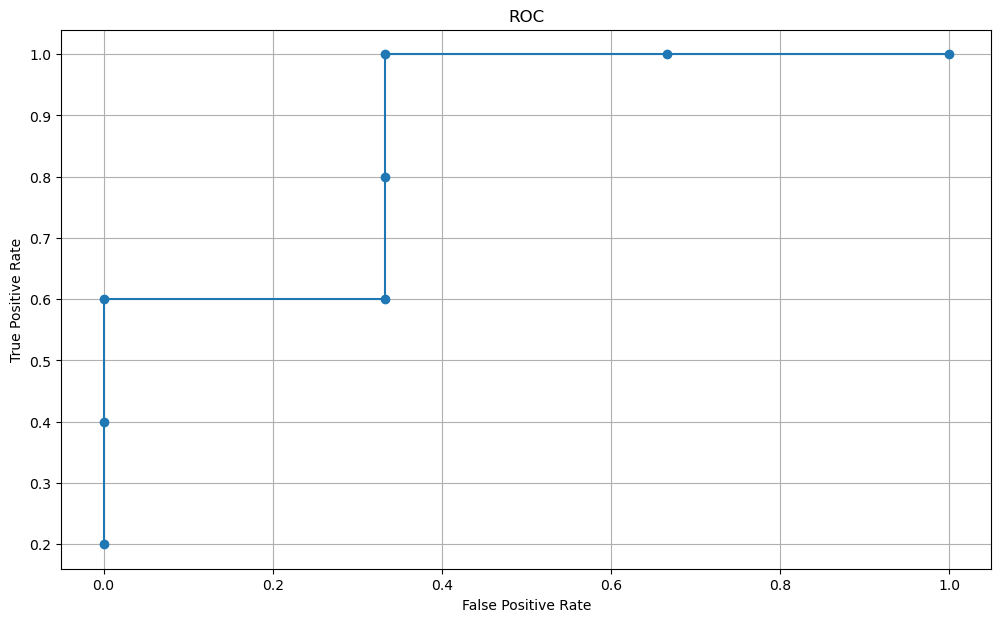

In [210]:
# YOUR CODE HERE
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 7))

plt.plot(roc_fpr, roc_tpr, "o-") #(x, y, "pontlinecolor")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC")
plt.grid(True)
plt.show()

### Exercise 3. Using the common packages

Now we have a better idea of how evaluation metrics work, we will go back to making some predictions on the Penguin dataset. 

Take another look at the penguin dataset. In exercise 1, we just discarded everything which has a NaN value.
For having a machine learning model in production, that would not generalize very well. 

We will again do a little bit of the data processing for you:


In [213]:
# Since we edited it before, let's load it again
penguins = pd.read_csv("penguin.csv")

features = ["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]
X = penguins[features].to_numpy()
predict_type = "Adelie"

penguins[predict_type] = penguins["species"] == predict_type
y = penguins[predict_type].to_numpy().astype(int)

random_size = 1
test_size = 0.25

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=test_size, random_state=1
)

### Exercise 3.1

Find if there are NaN values in X_train or X_test. You can use for example [isnan](https://numpy.org/doc/stable/reference/generated/numpy.isnan.html)  and [numpy any](https://numpy.org/doc/stable/reference/generated/numpy.any.html)

In [216]:
nans_in_train = None  # assign a singular boolean value to nans_in_train
nans_in_test = None  # assign a singular boolan value to nans_in_test

# YOUR CODE HERE
nans_in_train = np.any(np.isnan(X_train))  # assign a singular boolean value to nans_in_train
nans_in_test = np.any(np.isnan(X_test))  # assign a singular boolan value to nans_in_test

"""  
print(f"NaNs in X_train: {nans_in_train}")
print(f"NaNs in X_test: {nans_in_test}")
"""

nans_in_train = True  
nans_in_test =  False

In [218]:
"""Checks whether previous output is correct"""
"""DO NOT MODIFY THIS CELL"""


'DO NOT MODIFY THIS CELL'

### Exercise 3.2 

Use the [Scikit module for logistic regression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html) to train a model on 3 different training sets:


`X_null` : all nan values are substituted by 0, using all columns of X_train. 

Find a strategy how to impute all nan values by 0. 

`X_mean`: all nan values are substituted by the mean, using all columns of X_train. 

Read more about imputing with the mean value here: [imputing strategies](https://scikit-learn.org/stable/modules/generated/sklearn.impute.SimpleImputer.html) . 


`X_bill_length` : only train on the zeroth column, which is the bill length. Don't forget to then also only test on the zeroth column of the testset. Use one of the previous two imputation methods. 


For all three of these, compute the [Accuracy](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.accuracy_score.html) and print it.


In [221]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.impute import SimpleImputer

In [223]:
X_null = None
pred_null = None
acc_null = None

# YOUR CODE HERE
X_null = SimpleImputer(missing_values=np.nan, strategy = "constant", fill_value=0).fit_transform(X_train)
pred_null = LogisticRegression().fit(X_null, y_train).predict(X_test)
acc_null = accuracy_score(y_test, pred_null)

print(acc_null)

0.9883720930232558


In [225]:
X_mean = None
pred_mean = None
acc_mean = None

# YOUR CODE HERE
X_mean = SimpleImputer(missing_values=np.nan, strategy = "mean").fit_transform(X_train)
pred_mean = LogisticRegression().fit(X_mean, y_train).predict(X_test)
acc_mean = accuracy_score(y_test, pred_mean)

print(acc_mean)

0.9767441860465116


In [227]:
X_bill_length = None
pred_bill_length = None
acc_bill_length = None

# YOUR CODE HERE
X_bill_length = SimpleImputer(missing_values=np.nan, strategy = "mean").fit_transform(X_train[:, [0]])
pred_bill_length =  LogisticRegression().fit(X_bill_length, y_train).predict(X_test[:, [0]])
acc_bill_length = accuracy_score(y_test, pred_bill_length)

print(acc_bill_length)

0.9302325581395349


In [229]:
"""Checks whether previous output is correct"""
"""DO NOT MODIFY THIS CELL"""

'DO NOT MODIFY THIS CELL'

### Exercise 3.3

Which of these strategies do you think was best? Which one is the worst? Why?

YOUR ANSWER HERE

If I understood the question correctly, then the best strategy would be with X_null (nan replace by 0), since its accuracy is the highest. Accuracy is the percentage of correctly predicted data compared to all correct results.
Although both models have a high score, X_mean performed a little worse. 

Replacing by zero is better when the data is unevenly distributed, there are large outliers or a lot of them, and when this is an acceptable value. The average works worse if they are not symmetrically distributed or there are many large outliers, then the average value will not be accurate, which most likely happened here